In [1]:
import pandas as pd
import os
path = "/kaggle/input/datasets/arjungirdhar/tennis-dataset"
dfs = []
for file in os.listdir(path):
  if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(path, file))
        dfs.append(df)
        
matches = pd.concat(dfs, ignore_index=True) #ignore_index is used here to throw away old row numbers

print(matches.shape)
matches.head()

(36783, 49)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2024-0339,Brisbane,Hard,32,A,20240101,300,105777,2.0,NaN,...,58.0,44.0,16.0,11.0,8.0,9.0,14.0,2570.0,8.0,3660.0
1,2024-0339,Brisbane,Hard,32,A,20240101,299,208029,1.0,NaN,...,35.0,31.0,10.0,11.0,5.0,7.0,8.0,3660.0,39.0,1122.0
2,2024-0339,Brisbane,Hard,32,A,20240101,298,105777,2.0,NaN,...,39.0,24.0,14.0,10.0,5.0,7.0,14.0,2570.0,55.0,902.0
3,2024-0339,Brisbane,Hard,32,A,20240101,297,208029,1.0,NaN,...,51.0,31.0,16.0,10.0,3.0,5.0,8.0,3660.0,116.0,573.0
4,2024-0339,Brisbane,Hard,32,A,20240101,296,126128,NaN,NaN,...,37.0,27.0,16.0,10.0,5.0,8.0,39.0,1122.0,44.0,1021.0


In [2]:
matches["tourney_date"] = pd.to_datetime(
    matches["tourney_date"],
    format="%Y%m%d"
)

In [3]:
matches = matches.sort_values(
    "tourney_date"
).reset_index(drop=True)

In [4]:
matches[[
    "tourney_date",
    "winner_name",
    "loser_name",
    "surface"
]].head()

,tourney_date,winner_name,loser_name,surface
0,2018-01-01,Gilles Simon,Marin Cilic,Hard
1,2018-01-01,Marton Fucsovics,Nicolas Kicker,Hard
2,2018-01-01,Mikhail Kukushkin,Radu Albot,Hard
3,2018-01-01,Laslo Djere,Marius Copil,Hard
4,2018-01-01,Thiago Monteiro,Ruben Bemelmans,Hard


In [35]:
from collections import defaultdict

elo = defaultdict(lambda: 1500)

winner_elo_before = []
loser_elo_before = []

if row["tourney_level"] == "G":
    K = 40

elif row["tourney_level"] == "M":
    K = 36

elif row["tourney_level"] == "A":
    K = 32

else:
    K = 24

for _, row in matches.iterrows():

    winner = row["winner_id"]
    loser = row["loser_id"]

    Ra = elo[winner]
    Rb = elo[loser]

    winner_elo_before.append(Ra)
    loser_elo_before.append(Rb)

    expected_winner = 1 / (1 + 10 ** ((Rb - Ra) / 400))

    elo[winner] = Ra + K * (1 - expected_winner)
    elo[loser] = Rb + K * (0 - (1 - expected_winner))

matches["winner_elo"] = winner_elo_before
matches["loser_elo"] = loser_elo_before

In [6]:
matches[[
    "winner_name",
    "loser_name",
    "winner_elo",
    "loser_elo"
]].tail(20)

,winner_name,loser_name,winner_elo,loser_elo
36763,Sean Cuenin,Adrian Andreev,1711.680220,1512.322012
36764,Filip Cristian Jianu,Nicolo Toffanin,1677.010666,1428.803786
36765,Diego Dedura Palomero,Reda Bennani,1611.028848,1679.488594
36766,Filip Cristian Jianu,Ioannis Kountourakis,1683.195841,1375.578704
36767,Sean Cuenin,Filip Cristian Jianu,1719.389918,1687.850066
36768,Nicolo Toffanin,Fumin Jiang,1422.618611,1422.181838
36769,Alejo Sanchez Quilez,Amine Jamji,1574.329315,1450.141171
36770,Reda Bennani,Lenny Petit,1660.376085,1484.286554
36771,Silvio Mencaglia,Maxime Janvier,1426.064302,1489.082162
36772,Pierre Delage,Gabriele Mellerio,1598.403325,1490.311993


In [7]:
matches["elo_diff"] = (
    matches["winner_elo"]
    - matches["loser_elo"]
)
peak_elo = defaultdict(lambda: 1500)

In [8]:
peak_elo[winner] = max(peak_elo[winner], elo[winner])
peak_elo[loser] = max(peak_elo[loser], elo[loser])
print(peak_elo[winner])

1534.5009104170902


In [9]:
matches[[
    "winner_name",
    "loser_name",
    "winner_elo",
    "loser_elo"
]].tail()

,winner_name,loser_name,winner_elo,loser_elo
36778,Nicolas Garcia Longo,Atharva Sharma,1453.653595,1372.950004
36779,Sean Cuenin,Yuki Ikeda,1733.941431,1500.000000
36780,Iannis Miletich,Ghali Salah Eddine,1469.593989,1500.000000
36781,Sean Cuenin,Diego Dedura Palomero,1740.546694,1641.323901
36782,Yannik Kelm,Stefano Dagostino,1517.495489,1539.356751


In [10]:
#Surface Elo System

hard_elo = defaultdict(lambda: 1500)
clay_elo = defaultdict(lambda: 1500)
grass_elo = defaultdict(lambda: 1500)

winner_surface_elo = []
loser_surface_elo = []

K = 32

for _, row in matches.iterrows():

    winner = row["winner_id"]
    loser = row["loser_id"]
    surface = row["surface"]

    if surface == "Hard":
        ratings = hard_elo

    elif surface == "Clay":
        ratings = clay_elo

    elif surface == "Grass":
        ratings = grass_elo

    else:
        # skip Carpet and other rare surfaces
        winner_surface_elo.append(None)
        loser_surface_elo.append(None)
        continue

    Ra = ratings[winner]
    Rb = ratings[loser]

    winner_surface_elo.append(Ra)
    loser_surface_elo.append(Rb)

    Ea = 1 / (1 + 10 ** ((Rb - Ra) / 400))

    ratings[winner] = Ra + K * (1 - Ea)
    ratings[loser] = Rb + K * (0 - (1 - Ea))

matches["winner_surface_elo"] = winner_surface_elo
matches["loser_surface_elo"] = loser_surface_elo

matches["surface_elo_diff"] = (
    matches["winner_surface_elo"]
    - matches["loser_surface_elo"]
)

In [11]:
#code to only include active players

player_names = {}

for _, row in matches.iterrows():
    player_names[row["winner_id"]] = row["winner_name"]
    player_names[row["loser_id"]] = row["loser_name"]

player_match_counts = {}

for pid in player_names:

    player_match_counts[pid] = (
        (matches["winner_id"] == pid).sum()
        +
        (matches["loser_id"] == pid).sum()
    )

matches = matches.sort_values(
    "tourney_date"
).reset_index(drop=True)

last_match_date = {}

for _, row in matches.iterrows():

    last_match_date[row["winner_id"]] = row["tourney_date"]
    last_match_date[row["loser_id"]] = row["tourney_date"]

elite_matches = matches[
    matches["tourney_level"].isin(
        ["A", "M", "G", "D"]
    )
]

reference_date = elite_matches["tourney_date"].max()

print(reference_date)

active_players = {
    pid
    for pid, date in last_match_date.items()
    if (reference_date - date).days <= 365
}



2024-11-24 00:00:00


In [13]:
#code to check current all court rankings

filtered = [
    (pid, rating)
    for pid, rating in elo.items()
    if pid in active_players
    and player_match_counts.get(pid, 0) >= 75
]

filtered = sorted(
    filtered,
    key=lambda x: x[1],
    reverse=True
)

for pid, rating in filtered[:20]:
    print(
        player_names[pid],
        round(rating, 1),
        player_match_counts[pid]
    )

Jannik Sinner 2156.2 353
Novak Djokovic 2038.3 405
Carlos Alcaraz 1978.9 265
Alexander Zverev 1941.6 474
Taylor Fritz 1907.0 411
Daniil Medvedev 1861.1 475
Jack Draper 1843.4 130
Dane Sweeny 1835.7 83
Grigor Dimitrov 1834.2 336
Alex De Minaur 1820.3 403
Holger Rune 1816.7 228
Sebastian Korda 1808.1 206
Tommy Paul 1792.7 284
Rafael Nadal 1791.8 254
Karen Khachanov 1786.4 392
Stefanos Tsitsipas 1782.3 498
Hubert Hurkacz 1781.6 344
Ugo Humbert 1781.1 271
Matteo Berrettini 1776.7 288
Alex Molcan 1750.3 115


In [15]:
#code for hard court rankings

hard_filtered = [
    (pid, rating)
    for pid, rating in hard_elo.items()
    if pid in active_players
    and player_match_counts.get(pid, 0) >= 75
]

hard_filtered = sorted(
    hard_filtered,
    key=lambda x: x[1],
    reverse=True
)

for pid, rating in hard_filtered[:20]:
    print(
        player_names[pid],
        round(rating, 1),
        player_match_counts[pid]
    )

Jannik Sinner 2153.0 353
Novak Djokovic 2029.8 405
Carlos Alcaraz 1912.2 265
Alexander Zverev 1899.3 474
Daniil Medvedev 1859.3 475
Taylor Fritz 1854.0 411
Dane Sweeny 1825.7 83
Grigor Dimitrov 1823.5 336
Ugo Humbert 1801.5 271
Jack Draper 1789.7 130
Alex De Minaur 1782.3 403
Holger Rune 1779.3 228
Karen Khachanov 1767.6 392
Rafael Nadal 1760.8 254
Sebastian Korda 1760.4 206
Liam Broady 1741.9 108
Soon Woo Kwon 1733.2 162
Tommy Paul 1726.0 284
Hubert Hurkacz 1725.7 344
Ben Shelton 1724.6 123


In [16]:
#code for clay court rankings

clay_filtered = [
    (pid, rating)
    for pid, rating in clay_elo.items()
    if pid in active_players
    and player_match_counts.get(pid, 0) >= 75
]

clay_filtered = sorted(
    clay_filtered,
    key=lambda x: x[1],
    reverse=True
)

for pid, rating in clay_filtered[:20]:
    print(
        player_names[pid],
        round(rating, 1),
        player_match_counts[pid]
    )

Novak Djokovic 1919.4 405
Carlos Alcaraz 1918.0 265
Stefanos Tsitsipas 1861.3 498
Alexander Zverev 1860.2 474
Rafael Nadal 1840.9 254
Casper Ruud 1836.6 378
Matteo Berrettini 1830.5 288
Jannik Sinner 1781.3 353
Alex Molcan 1746.5 115
Lorenzo Musetti 1732.1 245
Andrey Rublev 1729.8 451
Jan Lennard Struff 1728.3 310
Holger Rune 1714.8 228
Taylor Fritz 1707.6 411
Felix Auger Aliassime 1704.8 364
Francisco Cerundolo 1703.2 190
Sebastian Baez 1702.6 179
Karen Khachanov 1702.5 392
Daniil Medvedev 1693.9 475
Hubert Hurkacz 1692.4 344


In [17]:
#code for grass court rankings

grass_filtered = [
    (pid, rating)
    for pid, rating in grass_elo.items()
    if pid in active_players
    and player_match_counts.get(pid, 0) >= 75
]

grass_filtered = sorted(
    grass_filtered,
    key=lambda x: x[1],
    reverse=True
)

for pid, rating in grass_filtered[:20]:
    print(
        player_names[pid],
        round(rating, 1),
        player_match_counts[pid]
    )

Novak Djokovic 1834.2 405
Carlos Alcaraz 1769.3 265
Matteo Berrettini 1725.6 288
Daniil Medvedev 1698.9 475
Jannik Sinner 1688.6 353
Alex De Minaur 1670.2 403
Tommy Paul 1667.6 284
Rafael Nadal 1663.1 254
Taylor Fritz 1658.3 411
Lorenzo Musetti 1645.1 245
Roberto Bautista Agut 1636.4 346
Hubert Hurkacz 1634.6 344
Marin Cilic 1631.8 262
Alexander Bublik 1624.0 292
Alexander Zverev 1622.2 474
Jack Draper 1622.0 130
Milos Raonic 1612.3 155
Andrey Rublev 1601.4 451
Sebastian Korda 1599.2 206
Jordan Thompson 1593.0 256


In [18]:
#code for all courts elo

ranking_df = pd.DataFrame([
    {
        "Player": player_names[pid],
        "Overall Elo": round(elo[pid], 1),
        "Hard Elo": round(hard_elo[pid], 1),
        "Clay Elo": round(clay_elo[pid], 1),
        "Grass Elo": round(grass_elo[pid], 1),
        "Matches": player_match_counts[pid]
    }
    for pid, _ in filtered
])

ranking_df.head(20)

,Player,Overall Elo,Hard Elo,Clay Elo,Grass Elo,Matches
0,Jannik Sinner,2156.2,2153.0,1781.3,1688.6,353
1,Novak Djokovic,2038.3,2029.8,1919.4,1834.2,405
2,Carlos Alcaraz,1978.9,1912.2,1918.0,1769.3,265
3,Alexander Zverev,1941.6,1899.3,1860.2,1622.2,474
4,Taylor Fritz,1907.0,1854.0,1707.6,1658.3,411
5,Daniil Medvedev,1861.1,1859.3,1693.9,1698.9,475
6,Jack Draper,1843.4,1789.7,1526.7,1622.0,130
7,Dane Sweeny,1835.7,1825.7,1500.0,1574.9,83
8,Grigor Dimitrov,1834.2,1823.5,1689.5,1559.1,336
9,Alex De Minaur,1820.3,1782.3,1672.9,1670.2,403


In [19]:
#specialists

ranking_df["Best Surface"] = ranking_df[
    ["Hard Elo","Clay Elo","Grass Elo"]
].max(axis=1)

ranking_df["Worst Surface"] = ranking_df[
    ["Hard Elo","Clay Elo","Grass Elo"]
].min(axis=1)

ranking_df["Surface Gap"] = (
    ranking_df["Best Surface"]
    - ranking_df["Worst Surface"]
)

ranking_df.sort_values(
    "Surface Gap",
    ascending=False
)[[
    "Player",
    "Hard Elo",
    "Clay Elo",
    "Grass Elo",
    "Surface Gap"
]].head(20)

,Player,Hard Elo,Clay Elo,Grass Elo,Surface Gap
0,Jannik Sinner,2153.0,1781.3,1688.6,464.4
17,Ugo Humbert,1801.5,1424.6,1559.7,376.9
35,Casper Ruud,1642.8,1836.6,1478.7,357.9
7,Dane Sweeny,1825.7,1500.0,1574.9,325.7
15,Stefanos Tsitsipas,1708.6,1861.3,1553.2,308.1
28,Jordan Thompson,1700.8,1403.7,1593.0,297.1
20,Liam Broady,1741.9,1522.5,1451.1,290.8
3,Alexander Zverev,1899.3,1860.2,1622.2,277.1
25,Alexei Popyrin,1713.9,1532.5,1441.9,272.0
8,Grigor Dimitrov,1823.5,1689.5,1559.1,264.4


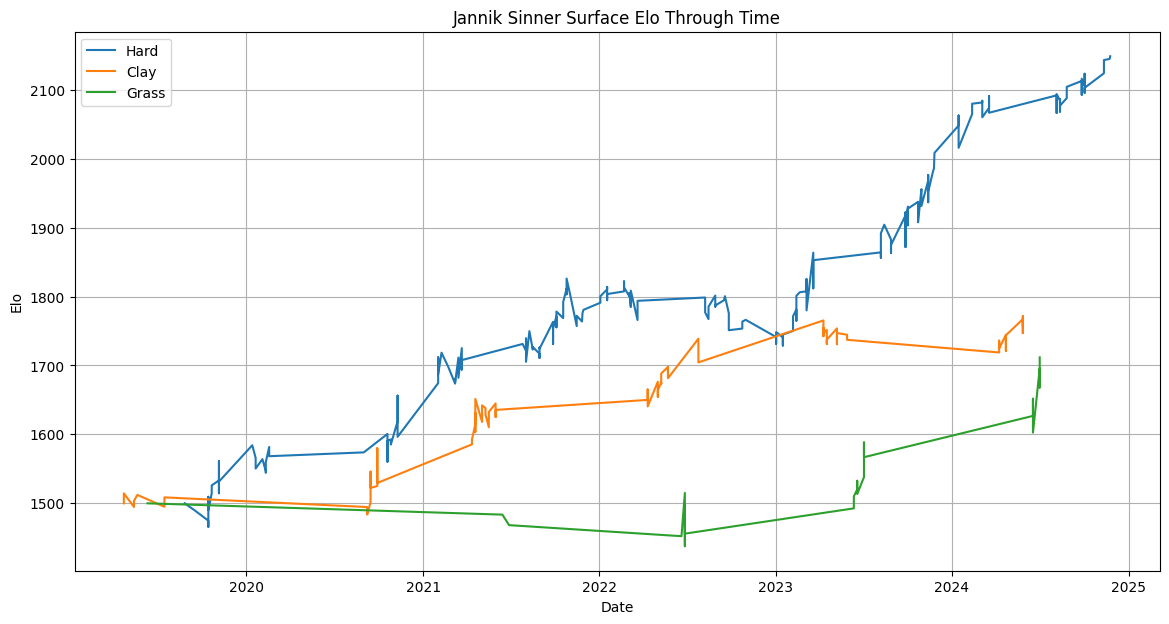

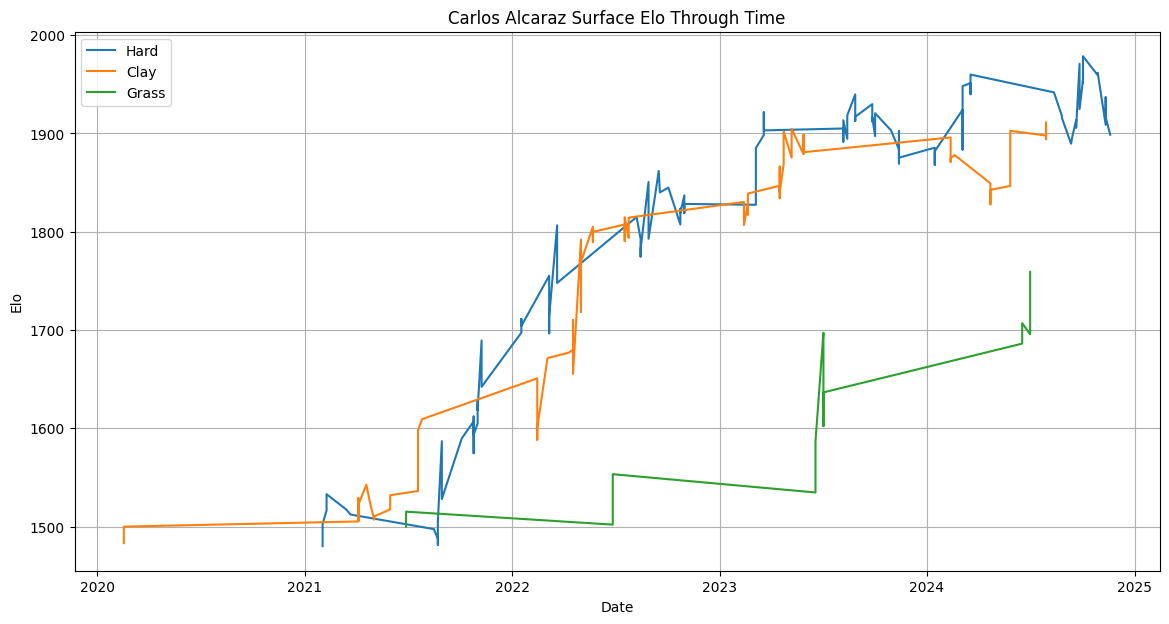

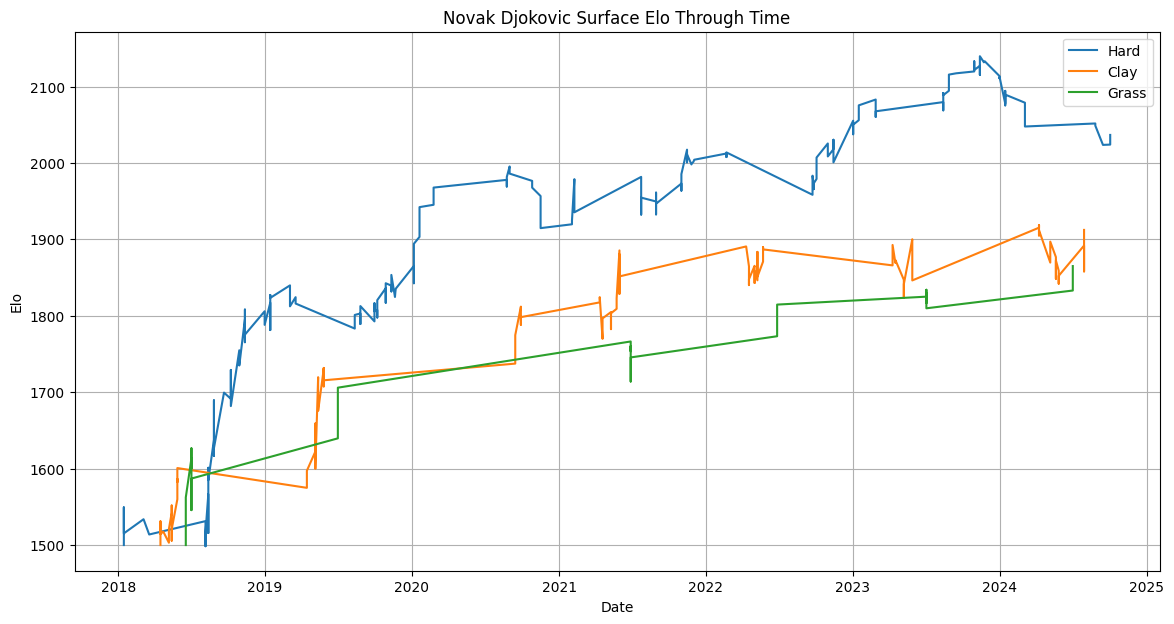

In [20]:
#graphing elo for top 3 players

from collections import defaultdict

hard_elo = defaultdict(lambda: 1500)

history = []

K = 32

for _, row in matches.iterrows():

    if row["surface"] != "Hard":
        continue

    winner = row["winner_id"]
    loser = row["loser_id"]

    Ra = hard_elo[winner]
    Rb = hard_elo[loser]

    history.append({
        "date": row["tourney_date"],
        "winner_name": row["winner_name"],
        "loser_name": row["loser_name"],
        "winner_elo": Ra,
        "loser_elo": Rb
    })

    Ea = 1 / (1 + 10 ** ((Rb - Ra)/400))

    hard_elo[winner] = Ra + K*(1-Ea)
    hard_elo[loser] = Rb - K*(1-Ea)

history_df = pd.DataFrame(history)

players = [
    "Jannik Sinner",
    "Carlos Alcaraz",
    "Novak Djokovic"
]

plot_data = []

for player in players:

    w = history_df[
        history_df["winner_name"] == player
    ][["date","winner_elo"]].rename(
        columns={"winner_elo":"elo"}
    )

    l = history_df[
        history_df["loser_name"] == player
    ][["date","loser_elo"]].rename(
        columns={"loser_elo":"elo"}
    )

    player_df = pd.concat([w,l])

    player_df["player"] = player

    plot_data.append(player_df)

plot_df = pd.concat(plot_data)


from collections import defaultdict

clay_elo = defaultdict(lambda: 1500)

clay_history = []

K = 32

for _, row in matches.iterrows():

    if row["surface"] != "Clay":
        continue

    winner = row["winner_id"]
    loser = row["loser_id"]

    Ra = clay_elo[winner]
    Rb = clay_elo[loser]

    clay_history.append({
        "date": row["tourney_date"],
        "winner_name": row["winner_name"],
        "loser_name": row["loser_name"],
        "winner_elo": Ra,
        "loser_elo": Rb
    })

    Ea = 1 / (1 + 10 ** ((Rb - Ra) / 400))

    clay_elo[winner] = Ra + K * (1 - Ea)
    clay_elo[loser] = Rb - K * (1 - Ea)

clay_history_df = pd.DataFrame(clay_history)

from collections import defaultdict

grass_elo = defaultdict(lambda: 1500)

grass_history = []

K = 32

for _, row in matches.iterrows():

    if row["surface"] != "Grass":
        continue

    winner = row["winner_id"]
    loser = row["loser_id"]

    Ra = grass_elo[winner]
    Rb = grass_elo[loser]

    grass_history.append({
        "date": row["tourney_date"],
        "winner_name": row["winner_name"],
        "loser_name": row["loser_name"],
        "winner_elo": Ra,
        "loser_elo": Rb
    })

    Ea = 1 / (1 + 10 ** ((Rb - Ra) / 400))

    grass_elo[winner] = Ra + K * (1 - Ea)
    grass_elo[loser] = Rb - K * (1 - Ea)

grass_history_df = pd.DataFrame(grass_history)

import matplotlib.pyplot as plt
import pandas as pd

def plot_surface_elo(player):

    plt.figure(figsize=(14,7))

    for surface_name, df in [
        ("Hard", history_df),
        ("Clay", clay_history_df),
        ("Grass", grass_history_df)
    ]:

        wins = (
            df[df["winner_name"] == player]
            [["date", "winner_elo"]]
            .rename(columns={"winner_elo": "elo"})
        )

        losses = (
            df[df["loser_name"] == player]
            [["date", "loser_elo"]]
            .rename(columns={"loser_elo": "elo"})
        )

        player_df = pd.concat([wins, losses])
        player_df = player_df.sort_values("date")

        plt.plot(
            player_df["date"],
            player_df["elo"],
            label=surface_name
        )

    plt.title(f"{player} Surface Elo Through Time")
    plt.xlabel("Date")
    plt.ylabel("Elo")
    plt.legend()
    plt.grid(True)

    plt.show()

plot_surface_elo("Jannik Sinner")
plot_surface_elo("Carlos Alcaraz")
plot_surface_elo("Novak Djokovic")

In [47]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# --------------------------------------------------
# 1) Clean and sort
# --------------------------------------------------
matches = matches.copy()

matches["tourney_date"] = pd.to_datetime(
    matches["tourney_date"],
    format="%Y%m%d",
    errors="coerce"
)

matches = matches.dropna(subset=[
    "tourney_date",
    "winner_id",
    "loser_id",
    "winner_name",
    "loser_name",
    "surface",
    "winner_rank",
    "loser_rank"
]).copy()

def normalize_surface(s):
    s = str(s).strip().lower()
    if "hard" in s:
        return "Hard"
    if "clay" in s:
        return "Clay"
    if "grass" in s:
        return "Grass"
    return "Other"

matches["surface"] = matches["surface"].apply(normalize_surface)
matches = matches.sort_values("tourney_date").reset_index(drop=True)

matches["winner_rank"] = pd.to_numeric(matches["winner_rank"], errors="coerce")
matches["loser_rank"] = pd.to_numeric(matches["loser_rank"], errors="coerce")

rank_fill = int(
    np.nanmax([matches["winner_rank"].max(), matches["loser_rank"].max()])
) + 50

matches["winner_rank"] = matches["winner_rank"].fillna(rank_fill)
matches["loser_rank"] = matches["loser_rank"].fillna(rank_fill)

# --------------------------------------------------
# 2) Player names
# --------------------------------------------------
player_names = {}
for _, row in matches.iterrows():
    player_names[row["winner_id"]] = row["winner_name"]
    player_names[row["loser_id"]] = row["loser_name"]

# --------------------------------------------------
# 3) Helpers
# --------------------------------------------------
def expected_score(ra, rb):
    return 1.0 / (1.0 + 10.0 ** ((rb - ra) / 400.0))

def blended_surface_elo(surface_elo, overall_elo, alpha=0.75):
    return alpha * surface_elo + (1 - alpha) * overall_elo

# --------------------------------------------------
# 4) Rating systems + form + head-to-head
# --------------------------------------------------
overall_elo = defaultdict(lambda: 1500.0)
surface_elos = {
    "Hard": defaultdict(lambda: 1500.0),
    "Clay": defaultdict(lambda: 1500.0),
    "Grass": defaultdict(lambda: 1500.0),
    "Other": defaultdict(lambda: 1500.0),
}

last10_overall = defaultdict(lambda: deque(maxlen=10))
last10_hard = defaultdict(lambda: deque(maxlen=10))
last10_clay = defaultdict(lambda: deque(maxlen=10))
last10_grass = defaultdict(lambda: deque(maxlen=10))

# Ordered head-to-head wins:
# h2h_wins[(a, b)] = number of times a beat b before the current match
h2h_wins = defaultdict(int)

K = 32
training_rows = []

for _, row in matches.iterrows():
    winner_id = row["winner_id"]
    loser_id = row["loser_id"]
    surface = row["surface"]

    # Pre-match ratings
    w_overall = overall_elo[winner_id]
    l_overall = overall_elo[loser_id]

    w_surface = surface_elos[surface][winner_id]
    l_surface = surface_elos[surface][loser_id]

    w_blended = blended_surface_elo(w_surface, w_overall, alpha=0.75)
    l_blended = blended_surface_elo(l_surface, l_overall, alpha=0.75)

    # Pre-match form
    w_last10_overall = sum(last10_overall[winner_id])
    l_last10_overall = sum(last10_overall[loser_id])

    w_last10_hard = sum(last10_hard[winner_id])
    l_last10_hard = sum(last10_hard[loser_id])

    w_last10_clay = sum(last10_clay[winner_id])
    l_last10_clay = sum(last10_clay[loser_id])

    w_last10_grass = sum(last10_grass[winner_id])
    l_last10_grass = sum(last10_grass[loser_id])

    # Pre-match head-to-head
    w_h2h = h2h_wins[(winner_id, loser_id)]
    l_h2h = h2h_wins[(loser_id, winner_id)]

    # Sample 1: winner as Player A
    training_rows.append({
        "date": row["tourney_date"],
        "surface": surface,
        "elo_diff": w_overall - l_overall,
        "blended_surface_elo_diff": w_blended - l_blended,
        "rank_diff": float(row["loser_rank"]) - float(row["winner_rank"]),
        "last10_overall_diff": w_last10_overall - l_last10_overall,
        "last10_hard_diff": w_last10_hard - l_last10_hard,
        "last10_clay_diff": w_last10_clay - l_last10_clay,
        "last10_grass_diff": w_last10_grass - l_last10_grass,
        "h2h_diff": w_h2h - l_h2h,
        "target": 1
    })

    # Sample 2: loser as Player A
    training_rows.append({
        "date": row["tourney_date"],
        "surface": surface,
        "elo_diff": l_overall - w_overall,
        "blended_surface_elo_diff": l_blended - w_blended,
        "rank_diff": float(row["winner_rank"]) - float(row["loser_rank"]),
        "last10_overall_diff": l_last10_overall - w_last10_overall,
        "last10_hard_diff": l_last10_hard - w_last10_hard,
        "last10_clay_diff": l_last10_clay - w_last10_clay,
        "last10_grass_diff": l_last10_grass - w_last10_grass,
        "h2h_diff": l_h2h - w_h2h,
        "target": 0
    })

    # Update overall Elo
    e_w = expected_score(w_overall, l_overall)
    overall_elo[winner_id] = w_overall + K * (1 - e_w)
    overall_elo[loser_id] = l_overall - K * (1 - e_w)

    # Update surface Elo
    e_ws = expected_score(w_surface, l_surface)
    surface_elos[surface][winner_id] = w_surface + K * (1 - e_ws)
    surface_elos[surface][loser_id] = l_surface - K * (1 - e_ws)

    # Update form
    last10_overall[winner_id].append(1)
    last10_overall[loser_id].append(0)

    if surface == "Hard":
        last10_hard[winner_id].append(1)
        last10_hard[loser_id].append(0)
    elif surface == "Clay":
        last10_clay[winner_id].append(1)
        last10_clay[loser_id].append(0)
    elif surface == "Grass":
        last10_grass[winner_id].append(1)
        last10_grass[loser_id].append(0)

    # Update head-to-head
    h2h_wins[(winner_id, loser_id)] += 1

# --------------------------------------------------
# 5) Build training dataframe
# --------------------------------------------------
train_df = pd.DataFrame(training_rows)
train_df = pd.get_dummies(train_df, columns=["surface"], drop_first=False)
train_df = train_df.sort_values("date").reset_index(drop=True)

print("Training DF shape:", train_df.shape)
print(train_df["target"].value_counts())

# --------------------------------------------------
# 6) Time-based split
# --------------------------------------------------
X = train_df.drop(columns=["target", "date"])
y = train_df["target"]

split_idx = int(len(train_df) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

# --------------------------------------------------
# 7) Train model
# --------------------------------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

# --------------------------------------------------
# 8) Evaluate
# --------------------------------------------------
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

print("\nTrain accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy :", accuracy_score(y_test, test_pred))

print("Train AUC:", roc_auc_score(y_train, train_proba))
print("Test AUC :", roc_auc_score(y_test, test_proba))

print("\nClassification report (test):")
print(classification_report(y_test, test_pred))

# --------------------------------------------------
# 9) Coefficients
# --------------------------------------------------
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.named_steps["clf"].coef_[0]
}).sort_values("coef", ascending=False)

print("\nCoefficients:")
print(coef_df)

# --------------------------------------------------
# 10) Prediction helper
# --------------------------------------------------
feature_columns = X.columns.tolist()

def predict_match(player_a_id, player_b_id, surface, rank_a, rank_b):
    surface = normalize_surface(surface)

    a_overall = overall_elo.get(player_a_id, 1500.0)
    b_overall = overall_elo.get(player_b_id, 1500.0)

    a_surface_raw = surface_elos[surface].get(player_a_id, 1500.0)
    b_surface_raw = surface_elos[surface].get(player_b_id, 1500.0)

    a_blended = blended_surface_elo(a_surface_raw, a_overall, alpha=0.75)
    b_blended = blended_surface_elo(b_surface_raw, b_overall, alpha=0.75)

    a_vs_b = h2h_wins.get((player_a_id, player_b_id), 0)
    b_vs_a = h2h_wins.get((player_b_id, player_a_id), 0)

    row = {
        "elo_diff": a_overall - b_overall,
        "blended_surface_elo_diff": a_blended - b_blended,
        "rank_diff": float(rank_b) - float(rank_a),
        "last10_overall_diff": sum(last10_overall[player_a_id]) - sum(last10_overall[player_b_id]),
        "last10_hard_diff": sum(last10_hard[player_a_id]) - sum(last10_hard[player_b_id]),
        "last10_clay_diff": sum(last10_clay[player_a_id]) - sum(last10_clay[player_b_id]),
        "last10_grass_diff": sum(last10_grass[player_a_id]) - sum(last10_grass[player_b_id]),
        "h2h_diff": a_vs_b - b_vs_a,
        "surface_Hard": 0,
        "surface_Clay": 0,
        "surface_Grass": 0,
        "surface_Other": 0
    }

    col_name = f"surface_{surface}"
    if col_name in row:
        row[col_name] = 1

    match_df = pd.DataFrame([row]).reindex(columns=feature_columns, fill_value=0)

    p_a = model.predict_proba(match_df)[0][1]
    p_b = 1 - p_a
    winner = "Player A" if p_a > p_b else "Player B"

    print("P(Player A wins):", p_a)
    print("P(Player B wins):", p_b)
    print("Predicted winner:", winner)

    return p_a, p_b, winner

Training DF shape: (65460, 14)
target
1    32730
0    32730
Name: count, dtype: int64

Train accuracy: 0.6537771157959059
Test accuracy : 0.6937060800488848
Train AUC: 0.7146049235001192
Test AUC : 0.7557705800162202

Classification report (test):
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      6544
           1       0.69      0.69      0.69      6548

    accuracy                           0.69     13092
   macro avg       0.69      0.69      0.69     13092
weighted avg       0.69      0.69      0.69     13092


Coefficients:
                     feature      coef
2                  rank_diff  0.421256
1   blended_surface_elo_diff  0.358414
0                   elo_diff  0.153801
4           last10_hard_diff  0.094779
3        last10_overall_diff  0.065381
5           last10_clay_diff  0.062892
7                   h2h_diff  0.040866
6          last10_grass_diff  0.029880
10              surface_Hard  0.000032
9              surfa

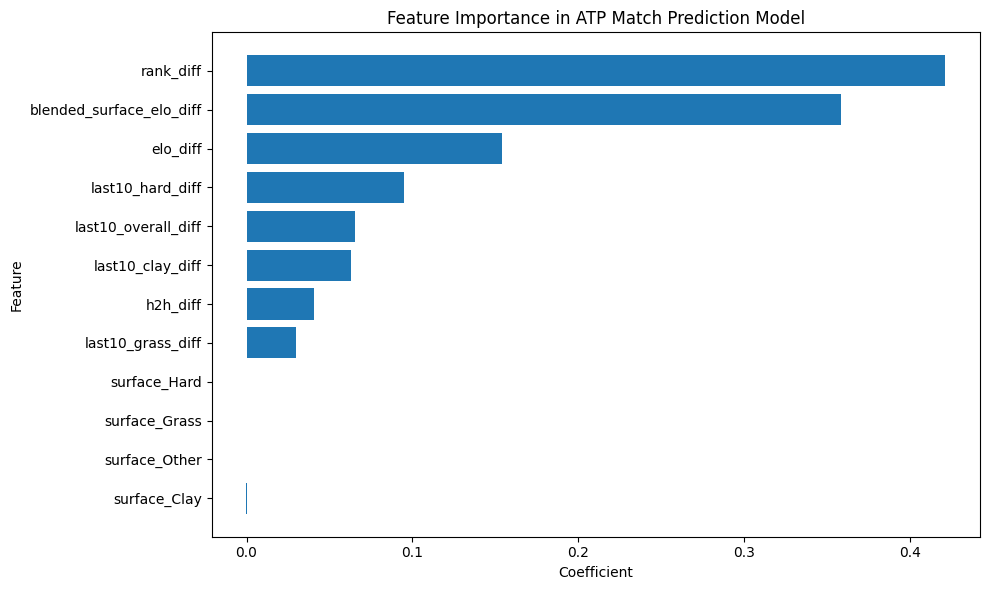

In [48]:
import matplotlib.pyplot as plt

# Sort by importance
plot_df = coef_df.sort_values("coef")

plt.figure(figsize=(10,6))

plt.barh(
    plot_df["feature"],
    plot_df["coef"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance in ATP Match Prediction Model")

plt.tight_layout()
plt.show()

In [50]:
name_to_id = {
    name.lower(): pid
    for pid, name in player_names.items()
}

def predict_by_name(player_a, player_b, surface):

    player_a_id = name_to_id[player_a.lower()]
    player_b_id = name_to_id[player_b.lower()]

    rank_a = 999
    rank_b = 999

    latest_matches = matches.sort_values("tourney_date")

    a_rows = latest_matches[
        (latest_matches["winner_id"] == player_a_id)
        |
        (latest_matches["loser_id"] == player_a_id)
    ]

    b_rows = latest_matches[
        (latest_matches["winner_id"] == player_b_id)
        |
        (latest_matches["loser_id"] == player_b_id)
    ]

    if len(a_rows) > 0:
        last = a_rows.iloc[-1]

        if last["winner_id"] == player_a_id:
            rank_a = last["winner_rank"]
        else:
            rank_a = last["loser_rank"]

    if len(b_rows) > 0:
        last = b_rows.iloc[-1]

        if last["winner_id"] == player_b_id:
            rank_b = last["winner_rank"]
        else:
            rank_b = last["loser_rank"]

    p_a, p_b, winner = predict_match(
        player_a_id,
        player_b_id,
        surface,
        rank_a,
        rank_b
    )

    print()
    print(f"{player_a}: {p_a*100:.2f}%")
    print(f"{player_b}: {p_b*100:.2f}%")

In [51]:
predict_by_name(
    "Jannik Sinner",
    "Carlos Alcaraz",
    "Clay"
)

P(Player A wins): 0.5337288555592739
P(Player B wins): 0.46627114444072615
Predicted winner: Player A

Jannik Sinner: 53.37%
Carlos Alcaraz: 46.63%
